In [ ]:
'''
K = 3 

01/30/2026
Implemented scheduler to reduce learning rate on plateau.
Added reconstruction MSE and BCE for training and val datasets.

02/01/2026
Added savehelper.py to save and load model and optimizer states.'''

'\nK = 3 \n\n01/30/2026\nImplemented scheduler to reduce learning rate on plateau.\n'

In [1]:
# pip install pyscipopt
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader   
import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms
import dwave.system
import dimod
from dwave.samplers import SimulatedAnnealingSampler
import json
from pyscipopt import Model, quicksum
import numpy as np
import dimod
import itertools
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, NonNegativeIntegers, Binary, summation, value, RangeSet

from optihelper import *
from torch.optim.lr_scheduler import ReduceLROnPlateau
from bolmaqua import *
from savehelper import *

In [2]:

def build_and_solve(G, K, V_target, H_target, tee=False, initial_visible_assignment=None): # new parameter initial_visible_assignment
    # Build Zephyr graph
    nodes = sorted(G.nodes())
    n = len(nodes)
    node_index = {i: idx for idx, i in enumerate(nodes)}

    edges = sorted(set((min(u, v), max(u, v)) for u, v in G.edges()))

    adj = {i: set() for i in nodes}
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)

    P = edges.copy()
    # P = [(i, j) for i in nodes for j in nodes if i < j]  # All pairs

    triples = []
    for (k, l) in P:
        common_neighbors = set(adj[k]).intersection(adj[l])
        for i in common_neighbors:
            triples.append((i, k, l))
    triples = list(set(triples))

    if not (0 <= V_target <= n):
        raise ValueError("V_target out of range")
    if not (0 <= H_target <= n):
        raise ValueError("H_target out of range")
    f_required = (n - V_target) - H_target
    if f_required < 0:
        raise ValueError(f"Impossible targets: need nonnegative fusions, got {f_required}")

    
    # Build SCIP model
    
    m = Model("NodeLabelOptimization")

    #  Variables 
    relax = False  # <-- toggle

    x = {i: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"x_{i}") for i in nodes}
    z = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"z_{p[0]}_{p[1]}") for p in P}
    y = {e: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"y_{e[0]}_{e[1]}") for e in edges}
    u = {t: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, name=f"u_{t[0]}_{t[1]}_{t[2]}") for t in triples}
    t_var = m.addVar(vtype="I", lb=0, name="t")

    # If initial visible assignment provided, use it as starting point
    if initial_visible_assignment is not None and not relax:
        initial_visible = set(initial_visible_assignment.values())
        print(f"Creating warm start with {len(initial_visible)} pre-assigned visible nodes")
        
        # Create a heuristic solution
        heur_sol = m.createPartialSol()
        
        # Set x variables based on initial assignment
        for i in nodes:
            if i in initial_visible:
                m.setSolVal(heur_sol, x[i], 1.0)
            else:
                m.setSolVal(heur_sol, x[i], 0.0)
        
        # Don't set z variables yet - let solver figure out fusions
        # Add the partial solution
        m.addSol(heur_sol, free=True)  # free=True allows solver to modify it
        print("Warm start added")

    
    # Constraints
    
    # 1) Visible node count
    m.addCons(quicksum(x[i] for i in nodes) == V_target, "visible_count")

    # # 2) Hidden target: sum x_i + sum z_kl = n - H_target
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")

    # # 2b) After fusions:
    # # - V-V fusions reduce visible count by 1 (two visible -> one visible)
    # # - H-H fusions reduce hidden count by 1 (two hidden -> one hidden)
    # # Let: vv_fusions = sum of z[(k,l)] where both k,l are initially visible
    # #      hh_fusions = sum of z[(k,l)] where both k,l are initially hidden

    # vv_fusion_sum = quicksum(z[(k,l)] * x[k] * x[l] for (k,l) in P)  # Approximate
    # hh_fusion_sum = quicksum(z[(k,l)] * (1-x[k]) * (1-x[l]) for (k,l) in P)  # Approximate

    # # Visible after fusion: V_target (initial) - vv_fusions
    # # Hidden after fusion: (n - V_target) (initial) - hh_fusions
    # # Constraint: Hidden after fusion = H_target
    # # So: (n - V_target) - hh_fusions = H_target
    # # Therefore: hh_fusions = n - V_target - H_target

    # m.addCons(hh_fusion_sum == n - V_target - H_target, "hidden_target_with_fusion")

    # Debug: Is the hidden target even achievable?
    print(f"\nFeasibility check:")
    print(f"  Total nodes: {n}")
    print(f"  Target visible: {V_target}")
    print(f"  Target hidden: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Maximum possible fusions (with matching): {len([i for i in nodes if len(adj[i]) > 0])}")

    # Debug: check if basic constraints are consistent
    m.addCons(quicksum(x[i] for i in nodes) + quicksum(z[p] for p in P) == n - H_target, "hidden_target")
    print(f" Added constraint: sum(x) + sum(z) = {n - H_target}")
    print(f"  This means: {V_target} visible + {n - V_target - H_target} fusions → {H_target} hidden")

    
    
    # # 3) Fusion only among hidden nodes
    for (k, l) in P:
        m.addCons(z[(k, l)] <= 1 - x[k], f"fusion1_{k}_{l}")
        m.addCons(z[(k, l)] <= 1 - x[l], f"fusion2_{k}_{l}")

    # # 3b) Fusion rules: Allow V-V fusion, but result must stay visible
    # # If both visible: fusion creates a new visible node
    # # If both hidden: fusion creates a new hidden node
    # # No V-H fusion (would be ambiguous)

    # # Add variable to track if fusion result is visible
    # z_result_visible = {p: m.addVar(vtype="C" if relax else "B", lb=0, ub=1, 
    #                                 name=f"zv_{p[0]}_{p[1]}") for p in P}

    # for (k, l) in P:
    #     # If both k,l are visible, fusion result must be visible
    #     # z_result_visible[(k,l)] >= x[k] + x[l] - 1
    #     m.addCons(z_result_visible[(k, l)] >= x[k] + x[l] - 1, f"vv_fusion1_{k}_{l}")
        
    #     # If fusion happens and both visible, result is visible
    #     # z_result_visible[(k,l)] <= (x[k] + x[l])/2 + M*(1-z[(k,l)])
    #     # Simplified: if z=1 and both x=1, then z_result_visible=1
    #     m.addCons(z_result_visible[(k, l)] <= x[k], f"vv_fusion2_{k}_{l}")
    #     m.addCons(z_result_visible[(k, l)] <= x[l], f"vv_fusion3_{k}_{l}")
        
    #     # No V-H fusion: if one is visible and one hidden, can't fuse
    #     # z[(k,l)] <= 1 - |x[k] - x[l]|
    #     # Use y[(k,l)] which already computes |x[k] - x[l]|
    #     if (min(k,l), max(k,l)) in y:
    #         m.addCons(z[(k, l)] <= 1 - y[(min(k, l), max(k, l))], f"no_vh_fusion_{k}_{l}")

    # # 4) Matching constraint: node participates in ≤ 1 fusion
    # for i in nodes:
    #     nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
    #     if nbrs:
    #         m.addCons(quicksum(z[p] for p in nbrs) <= 1 - x[i], f"match_{i}")

    # 5) Linearize y_ij = |x_i - x_j|
    for (i, j) in edges:
        m.addCons(y[(i, j)] >= x[i] - x[j])
        m.addCons(y[(i, j)] >= x[j] - x[i])
        m.addCons(y[(i, j)] <= x[i] + x[j])
        m.addCons(y[(i, j)] <= 2 - (x[i] + x[j]))

    # 6) Linearize u_{i,kl} = x_i * z_{kl}
    for (i, k, l) in triples:
        m.addCons(u[(i, k, l)] <= x[i])
        m.addCons(u[(i, k, l)] <= z[(k, l)])
        m.addCons(u[(i, k, l)] >= x[i] + z[(k, l)] - 1)

    # 7) Maximin constraint: t <= c_i + M*x_i
    max_deg = max(len(adj[i]) for i in nodes)
    M = max_deg
    for i in nodes:
        c_i0 = quicksum(y[(min(i, j), max(i, j))] for j in adj[i])
        losses = quicksum(u[t] for t in triples if t[0] == i)
        c_i_expr = c_i0 - losses
        m.addCons(t_var <= c_i_expr + M * x[i], f"maximin_{i}")

    # 8) Upper bound for t
    m.addCons(t_var <= max_deg, "t_upper")

    # 8b) Lower bound for t based on empirical evidence
    m.addCons(t_var >= 4, "t_lower_bound")
    print("Added constraint: t >= 4 (empirically achievable)")


    # Objective: maximize t
    m.setObjective(t_var, "maximize")

    # m.setObjective(quicksum(z[p] for p in P), "maximize")  # Just maximize fusions

   
    # Solve
    m.setParam("limits/time", 5)
    m.setParam("display/verblevel", 5 if tee else 0)
    m.setParam("limits/gap", 0.2)

    print(f"K={K}, n={n}, V_target={V_target}, H_target={H_target}")
    print(f"f_required = {(n - V_target) - H_target}")
    print(f"Max possible fusions (n/2) = {n//2}")
    print(f"Total edges = {len(edges)}")

    # Debug: check if basic constraints are consistent
    print("\nPre-solve check:")
    print(f"  Nodes: {len(nodes)}")
    print(f"  V_target: {V_target}")
    print(f"  H_target: {H_target}")
    print(f"  Required fusions: {n - V_target - H_target}")
    print(f"  Available fusion pairs: {len(P)}")

    if (n - V_target - H_target) > len(P):
        print("  WARNING: Not enough fusion pairs available!")
    m.optimize()

    status = m.getStatus()
    print(f"Solver status: {status}")

    # Debug
    # actual_fusions = sum(1 for val in z_vals.values() if val > 0.5)
    # print(f"\nConstraint check:")
    # print(f"  sum(x) = {sum(x_vals.values())}")
    # print(f"  sum(z) = {sum(z_vals.values())} (actual: {actual_fusions} binary)")
    # print(f"  sum(x) + sum(z) = {sum(x_vals.values()) + sum(z_vals.values())}")
    # print(f"  Target: {n - H_target}")
    # print(f"  Difference: {abs(sum(x_vals.values()) + sum(z_vals.values()) - (n - H_target))}")

    # Extract results
   
    # after m.optimize() and checking m.getNSols() > 0
    sol = m.getBestSol()

    # Time limit reached without feasible solution
    if sol is None:
        print(" NO SOLUTION FOUND: Solver hit time limit before finding feasible solution.")
        print("   Returning empty solution:")
        return {
            "model": m,
            "x": {i: 0.0 for i in nodes},
            "z": {p: 0.0 for p in P},
            "y": {e: 0.0 for e in edges},
            "u": {t: 0.0 for t in triples},
            "t": 0.0,
            "c0": {i: 0.0 for i in nodes},
            "losses": {i: 0.0 for i in nodes},
            "c_eff": {i: 0.0 for i in nodes},
            "G_original": G,
            "G_contracted": G.copy(),
            "fused_map": {}
        }

    # raw floats
    x_vals = {i: m.getSolVal(sol, x[i]) for i in nodes}
    z_vals = {p: m.getSolVal(sol, z[p]) for p in P}
    y_vals = {e: m.getSolVal(sol, y[e]) for e in edges}
    u_vals = {t: m.getSolVal(sol, u[t]) for t in triples}
    t_val = m.getSolVal(sol, t_var)

    # quick summaries
    print("SUM x (float) =", sum(x_vals.values()))
    print("SUM z (float) =", sum(z_vals.values()))
    print("SUM y (float) =", sum(y_vals.values()))
    print("t (float) =", t_val)

    # show top nonzero vars
    print("Top x (nonzero):", [(i, round(x_vals[i],3)) for i in nodes if x_vals[i] > 1e-6][:20])
    print("Top z (nonzero):", [(p, round(z_vals[p],3)) for p in P if z_vals[p] > 1e-6][:20])
    print("Top y (nonzero):", [(e, round(y_vals[e],3)) for e in edges if y_vals[e] > 1e-6][:20])

    # Compute effective c_i
    c0 = {}
    losses = {}
    c_eff = {}
    for i in nodes:
        nbrs = [(min(i, j), max(i, j)) for j in adj[i]]
        c0[i] = sum(y_vals.get(p, 0.0) for p in nbrs)
        losses[i] = sum(u_vals.get(t, 0.0) for t in triples if t[0] == i)
        c_eff[i] = c0[i] - losses[i]

  
   
    # Build contracted graph (apply fusions)
    G_contracted = G.copy()
    fused_map = {}  # maps original node to final representative

    # Group fusions by connected components
    fusion_edges = [(k, l) for (k, l), val in z_vals.items() if val > 0.99]  # use threshold for float tolerance

    # Build fusion graph to find connected components
    fusion_graph = nx.Graph()
    fusion_graph.add_nodes_from(nodes)
    fusion_graph.add_edges_from(fusion_edges)

    # Each connected component gets fused into one node
    for component in nx.connected_components(fusion_graph):
        if len(component) == 1:
            continue  # singleton, no fusion needed
        
        # Pick representative (eg, smallest node)
        rep = min(component)
        rep_name = "_".join(map(str, sorted(component)))
        
        # Collect all neighbors from all nodes in component
        all_neighbors = set()
        for node in component:
            if node in G_contracted:
                all_neighbors.update(G_contracted.neighbors(node))
        
        # Remove nodes being fused from neighbor set
        all_neighbors -= component
        
        # Add new representative node
        if rep_name not in G_contracted:
            G_contracted.add_node(rep_name)
        
        # Connect representative to all external neighbors
        for nb in all_neighbors:
            if nb not in component:  # don't self-loop
                G_contracted.add_edge(rep_name, nb)
        
        # Remove original nodes
        for node in component:
            if node in G_contracted:
                G_contracted.remove_node(node)
            fused_map[node] = rep_name

    print(f"Objective t = {t_val}")
    print("Visible nodes (x_i=1):", [i for i, xv in x_vals.items() if xv == 1])
    print("Fusions (z_{k,l}=1):", [p for p, zv in z_vals.items() if zv == 1])
    print("Effective cross-edges per node (c_eff):")
    for i in nodes:
        print(f" node {i}: x={x_vals[i]}, c0={c0[i]}, losses={losses[i]}, c_eff={c_eff[i]}")

    return {
        "model": m,
        "x": x_vals,
        "z": z_vals,
        "y": y_vals,
        "u": u_vals,
        "t": t_val,
        "c0": c0,
        "losses": losses,
        "c_eff": c_eff,
        "G_original": G,
        "G_contracted": G_contracted,
        "fused_map": fused_map
    }


In [3]:
K = 3
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
nodes = sorted(G.nodes())
print('K =', K, 'n =', n, 'n/K =', n/K, 'n/(32*K^2) =', n/(32*K**2+16*K))
print("Toal number of edges:", G.number_of_edges())
V_target = 144 
H_target =  64


# Call this before building SCIP model:
max_possible = analyze_fusion_potential(G, nodes, V_target)
required = (n - V_target) - H_target

if max_possible < required:
    print(f"\n INFEASIBLE: Graph structure allows only {max_possible} fusions, need {required}!")
    print(f"   → H_target={H_target} is impossible. Minimum achievable: {n - V_target - max_possible}")

K = 3 n = 336 n/K = 112.0 n/(32*K^2) = 1.0
Toal number of edges: 2808

 Fusion Potential Analysis 
  Hidden nodes: 192
  Connected components in hidden subgraph: 1
  Maximum fusions possible: 191
  Component sizes: [192]...


In [4]:
# Use before optimization:
G_original = dnx.zephyr_graph(K)
df_analysis = analyze_zephyr_layout(G_original, K)



 Top 20 nodes by degree 
    node  degree         x         y  dist_from_center
25    25      20  0.146453 -0.427918          0.361495
28    28      20  0.157895 -0.574371          0.350534
31    31      20  0.183066 -0.427918          0.325712
34    34      20  0.194508 -0.574371          0.314836
37    37      20  0.219680 -0.427918          0.290137
40    40      20  0.231121 -0.574371          0.279374
43    43      20  0.256293 -0.427918          0.254855
46    46      20  0.267735 -0.574371          0.244253
49    49      20  0.292906 -0.427918          0.220009
52    52      20  0.304348 -0.574371          0.209643
55    55      20  0.329519 -0.427918          0.185843
58    58      20  0.340961 -0.574371          0.175846
61    61      20  0.366133 -0.427918          0.152816
64    64      20  0.377574 -0.574371          0.143439
67    67      20  0.402746 -0.427918          0.121855
70    70      20  0.414188 -0.574371          0.113616
73    73      20  0.439359 -0.427918   

Removing 64 edge nodes (degree < 12)
  Original nodes: 336
  Cleaned nodes: 272
  Degree distribution after cleaning: min=9, max=20
Assigned 144 pixels to nodes
  Center pixel (0,0) -> node 256 with degree 20
Creating warm start with 144 pre-assigned visible nodes
Warm start added

Feasibility check:
  Total nodes: 272
  Target visible: 144
  Target hidden: 64
  Required fusions: 64
  Maximum possible fusions (with matching): 272
 Added constraint: sum(x) + sum(z) = 208
  This means: 144 visible + 64 fusions → 64 hidden
Added constraint: t >= 4 (empirically achievable)
K=3, n=272, V_target=144, H_target=64
f_required = 64
Max possible fusions (n/2) = 136
Total edges = 2232

Pre-solve check:
  Nodes: 272
  V_target: 144
  H_target: 64
  Required fusions: 64
  Available fusion pairs: 2232
Solver status: timelimit
SUM x (float) = 144.0
SUM z (float) = 64.0
SUM y (float) = 1776.0
t (float) = 8.0
Top x (nonzero): [(0, 1.0), (1, 1.0), (2, 1.0), (3, 1.0), (4, 1.0), (5, 1.0), (6, 1.0), (7, 1.0

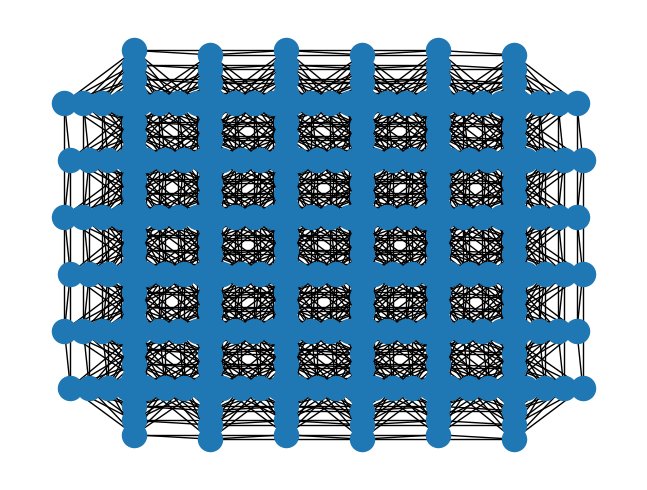

In [ ]:
grid_shape = (12, 12)
dnx.draw_zephyr(G)

# Removing edge nodes
G_clean = remove_edge_nodes(
        G_original, min_degree= 12)  # Adjust threshold as needed


# G_reduced = preprocess_graph(G_clean, V_target=144, H_target=32)

# Pixel-to-node assignment
pixel_to_node, node_to_pixel = assign_pixels_to_nodes_heuristic(
    G_clean, num_pixels=V_target, grid_shape=grid_shape)
    
initial_visible_nodes = set(pixel_to_node.values())
 
sol = build_and_solve(G_clean, K=K, V_target=V_target, H_target=H_target, tee=True, initial_visible_assignment=pixel_to_node)


In [ ]:
# # STORING OPTIMIZATION RESULTS TO JSON
# save_optimization_results('K3_optimization_7200s_260131_(test).json', sol)

# # Loading optimization results from JSON
# sol = load_optimization_results('K3_optimization_7200s_260131.json')

# print(f"Loaded optimization results:")
# print(f"  Nodes: {sol['G_original'].number_of_nodes()}")
# print(f"  Objective t: {sol['t']}")
# print(f"  Visible nodes: {sum(1 for v in sol['x'].values() if v > 0.5)}")
# print(f"  Fusions: {sum(1 for v in sol['z'].values() if v > 0.5)}")

Loaded optimization results:
  Nodes: 336
  Objective t: 6.0
  Visible nodes: 144
  Fusions: 128


In [ ]:
x_vals = sol["x"]
z_vals = sol["z"]
G_new = sol["G_original"]
print(x_vals)

G_fused, visible_nodes, hidden_nodes, clean_to_fused = apply_fusions_to_graph_clean(
    G_new, 
    x_vals, 
    z_vals,
)

# Greedy post-processing to reach exact target
G_contracted, visible_nodes, hidden_nodes = postprocess_fuse_hidden(
    G_fused, visible_nodes, hidden_nodes, H_target)


print(f"\nFinal result:")
print(f"  Visible: {len(visible_nodes)} (target: 144)")
print(f"  Hidden: {len(hidden_nodes)} (target: 32)")


=== Pre-Fusion Status ===
  Visible nodes: 144
  Hidden nodes: 128
  Fusions applied: 64

=== Relabeling to consecutive integers ===
  Relabeled nodes: 0 to 207
  Visible IDs: 0 to 143
  Hidden IDs: 144 to 207

=== POST-PROCESSING: Fuse 64 → 64 hidden nodes ===
  Already at or below target!

Final result:
  Visible: 144 (target: 144)
  Hidden: 64 (target: 32)


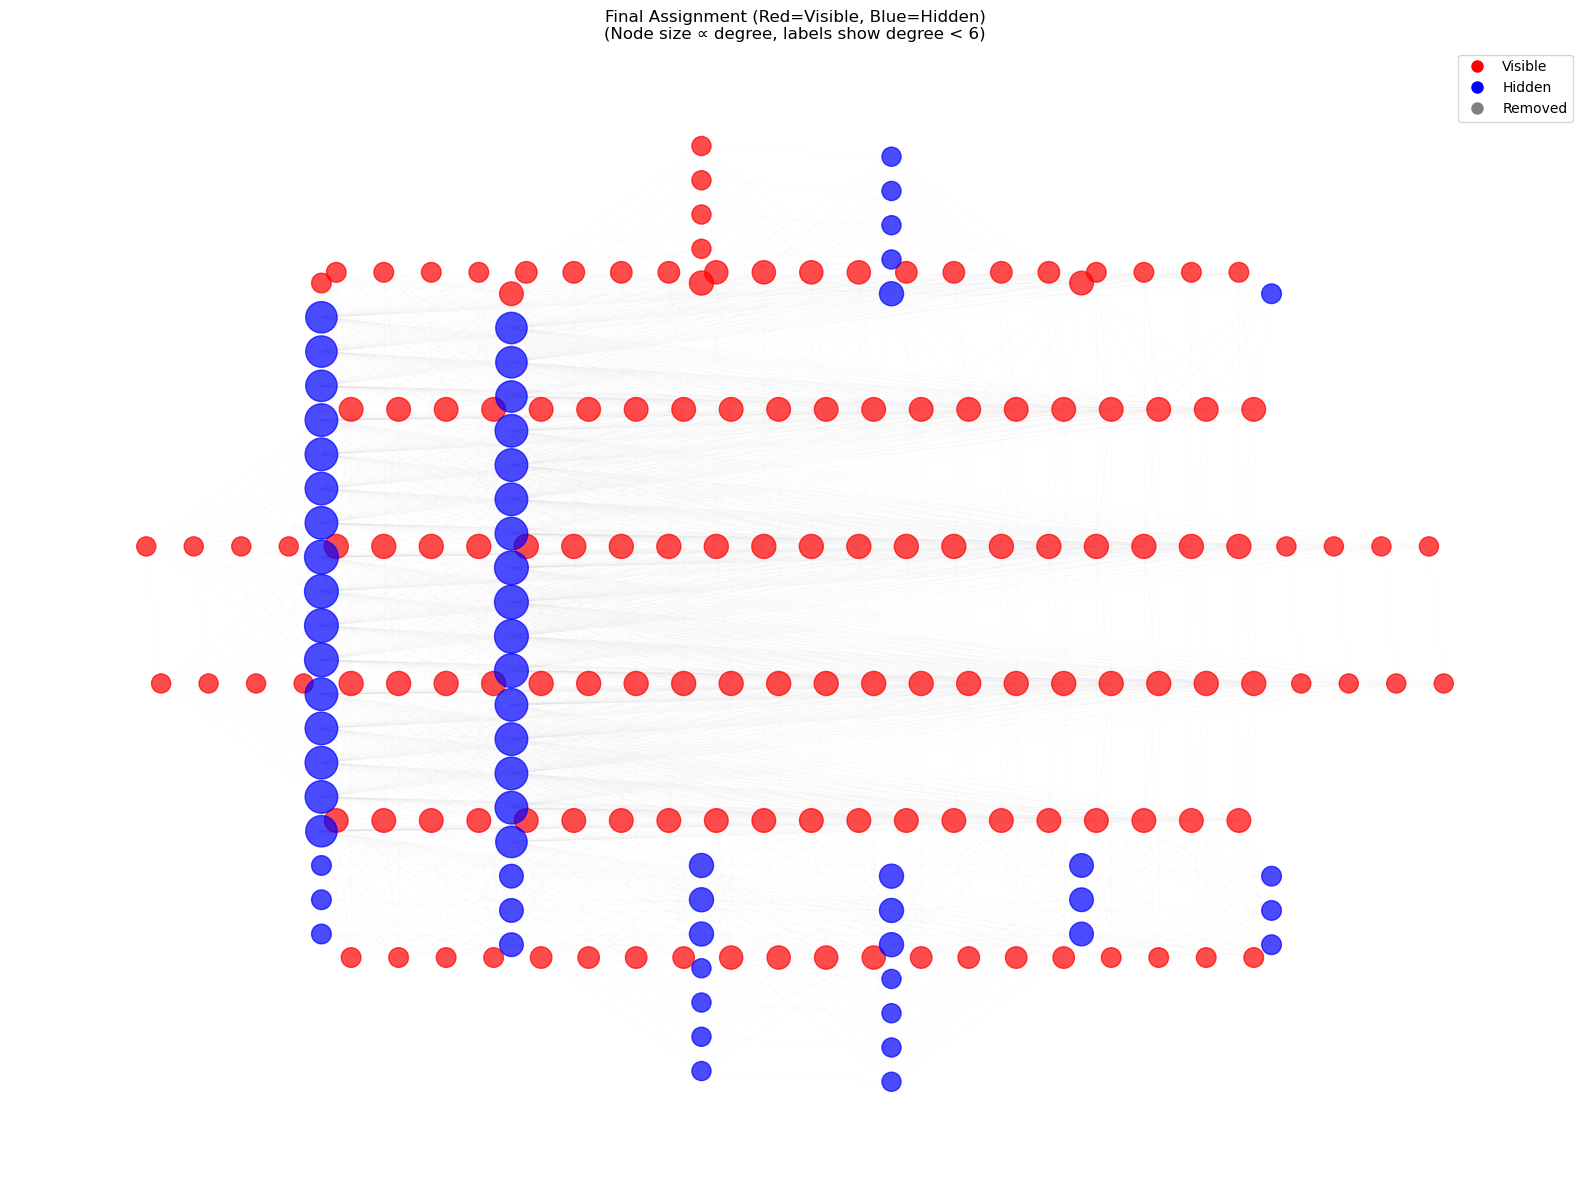

In [7]:
# G_contracted = G_fused
visualize_node_assignment_on_zephyr(G_contracted, visible_nodes, hidden_nodes, 
                                    title="Final Assignment (Red=Visible, Blue=Hidden)")

In [8]:


print(f"\nAfter fusion:")
print(f"  Original nodes: {sol['G_original'].number_of_nodes()}")
print(f"  Contracted nodes: {G_contracted.number_of_nodes()}")
print(f"  Visible: {len(visible_nodes)}")
print(f"  Hidden: {len(hidden_nodes)}")
print(f"  Expected hidden: {H_target}")

# Relabel for training
G, visible_nodes, hidden_nodes, relabel_mapping = relabel_for_training(
    G_contracted, visible_nodes, hidden_nodes
)

print(f"\nRelabeled graph:")
print(f"  Visible node IDs: 0 to {len(visible_nodes)-1}")
print(f"  Hidden node IDs: {len(visible_nodes)} to {len(visible_nodes)+len(hidden_nodes)-1}")

# G = G_contracted

# Create training structures
# Create vh_nodearray (1 for visible, 0 for hidden)
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)

# Mark visible nodes as 1
for v in visible_nodes:
    vh_nodearray[v] = 1

# Create node_labels dictionary
node_labels = {i: ('visible' if vh_nodearray[i] == 1 else 'hidden') 
               for i in range(n)}

# Update global variables
NUM_VISIBLE = len(visible_nodes)
NUM_HIDDEN = len(hidden_nodes)

print(f"\n✓ Ready for training:")
print(f"  Total nodes: {n}")
print(f"  Visible nodes: {NUM_VISIBLE}")
print(f"  Hidden nodes: {NUM_HIDDEN}")
print(f"  vh_nodearray shape: {vh_nodearray.shape}")

# Graph with layer info
for v in visible_nodes:
    G.nodes[v]["layer"] = "visible"
for h in hidden_nodes:
    G.nodes[h]["layer"] = "hidden"


After fusion:
  Original nodes: 272
  Contracted nodes: 208
  Visible: 144
  Hidden: 64
  Expected hidden: 64
Relabeling complete:
  Old node types: {'int'}
  New node IDs: all integers [0, 207]

Relabeled graph:
  Visible node IDs: 0 to 143
  Hidden node IDs: 144 to 207

✓ Ready for training:
  Total nodes: 208
  Visible nodes: 144
  Hidden nodes: 64
  vh_nodearray shape: (208,)


 Cross-edges (V-H): 1776 out of 2104
 Visible nodes: 144
 Hidden nodes: 64


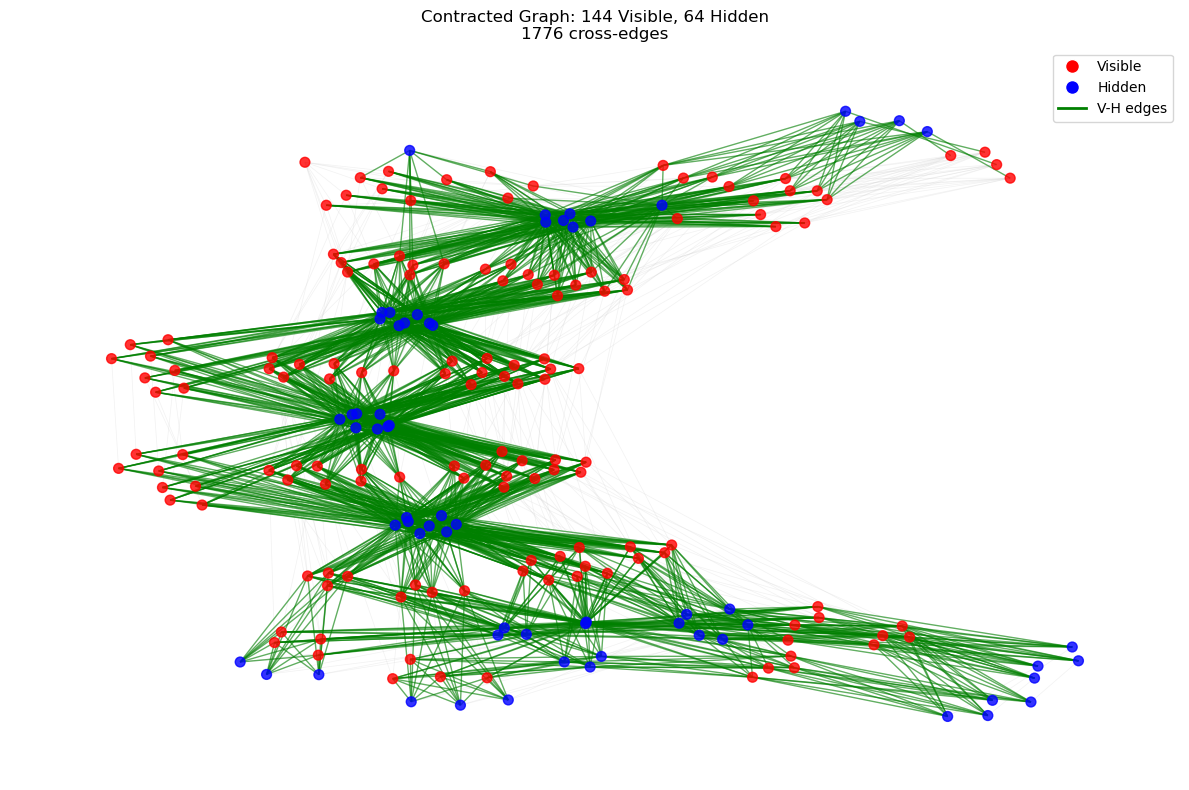

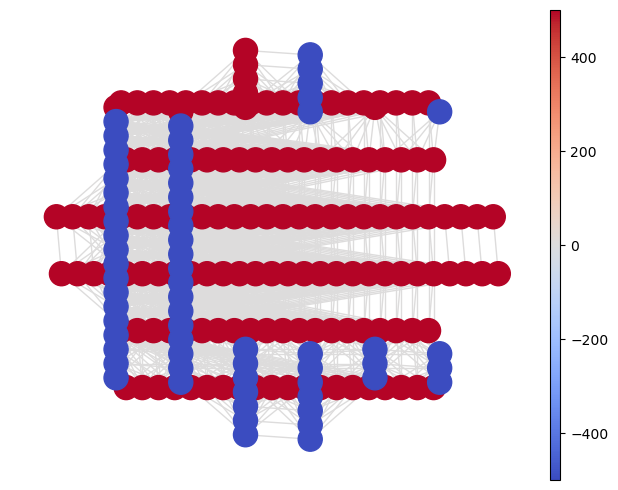

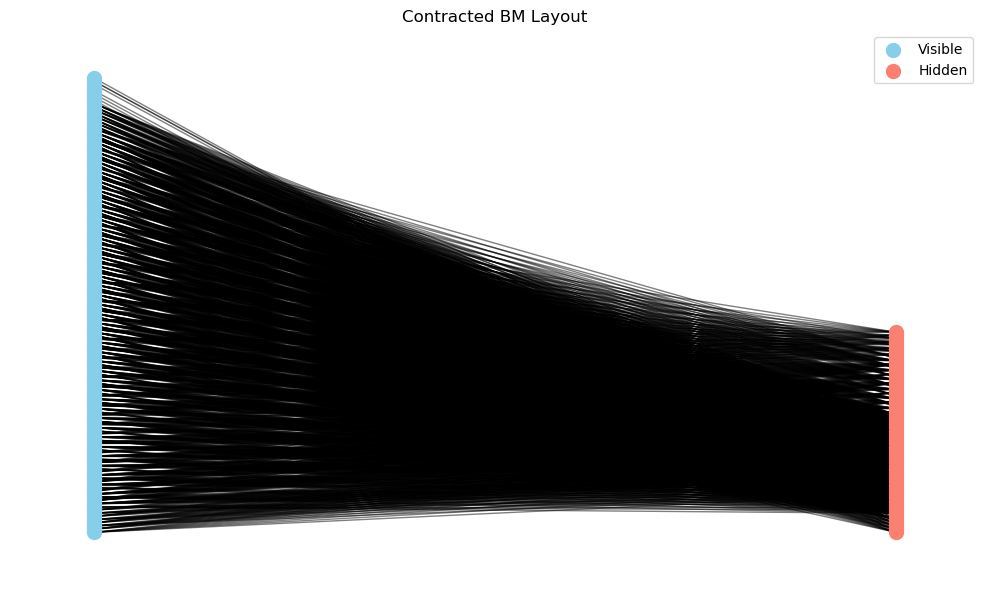

In [ ]:

# Visualize the relabeled graph
x_sol = visualize_contracted_graph(G, visible_nodes, hidden_nodes, use_zephyr_layout=False)

# original Zephyr visualization (if it works with contracted graph)
try:
    draw_zephyr_hidden_visible(G, vh_nodearray)
except Exception as e:
    print(f" Zephyr visualization doesn't work on contracted graph: {e}")


# Use the bipartite layout from bolmaqua.py
visualize_bm_bipartite_layout(G, node_labels, title="Contracted BM Layout")

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([12665, 144])


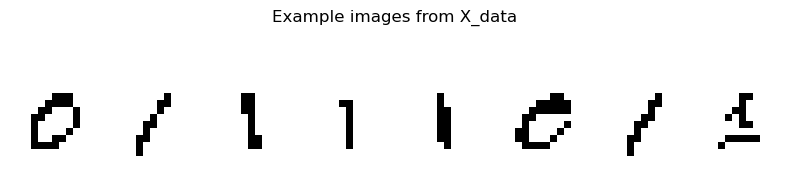

In [10]:

# --- Dataset Loading ---
# Using torchvision to download MNIST and then resize
def generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE, cutoff=0.5):
    """
    Generates downsized MNIST .npy files (from torchvision MNIST, not CSV).
    Resizes 28x28 MNIST images to `grid_shape` (e.g., 12x12, 13x13).
    Saves features and labels as .npy for reuse.
    """
    os.makedirs(output_dir, exist_ok=True)

    def process_dataset(dataset, cutoff):
        downsized, labels = [], []
        for img, label in dataset:
            # torchvision MNIST returns a PIL image unless transform is ToTensor
            img_np = np.array(img, dtype=np.float32)

            # If shape is (28,28,1), squeeze it
            if img_np.ndim == 3:
                img_np = img_np.squeeze(-1)

            img_np = img_np / 255.0  # scale to [0,1]
            img_small = resize(img_np, grid_shape, order=1, anti_aliasing=True, preserve_range=True)

            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin.flatten())
            labels.append(label)
        return np.array(downsized), np.array(labels)

    # Load MNIST from torchvision (downloads automatically if not present)
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=None)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

    for split, dataset in [("train", train_data), ("test", test_data)]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_dataset(dataset, cutoff)
            print("Processed feats shape:", feats.shape) # Debug print
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )



# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
# num_images_to_use = 200
# mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())

# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float() # default is < 0.5
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Split into training and validation sets
train_size = int(0.9 * len(X_data))
X_train = X_data[:train_size]
X_val = X_data[train_size:]

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
train_dataset = torch.utils.data.TensorDataset(X_train, torch.zeros(len(X_train)))
val_dataset = torch.utils.data.TensorDataset(X_val, torch.zeros(len(X_val)))

dataset = torch.utils.data.TensorDataset(X_data, torch.zeros(len(X_data)))

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

In [11]:
# Create fresh node_labels dictionary
node_labels = {}
for node in G.nodes():
    if node in visible_nodes:
        node_labels[node] = 'visible'
    elif node in hidden_nodes:
        node_labels[node] = 'hidden'
    else:
        print(f"Warning: Node {node} not in visible or hidden lists!")
        node_labels[node] = 'hidden'  # Default to hidden

# Verify all nodes are covered
print(f"\n=== Node Label Check ===")
print(f"  Graph nodes: {G.number_of_nodes()}")
print(f"  Labeled nodes: {len(node_labels)}")
print(f"  Visible labeled: {sum(1 for v in node_labels.values() if v == 'visible')}")
print(f"  Hidden labeled: {sum(1 for v in node_labels.values() if v == 'hidden')}")

if set(G.nodes()) != set(node_labels.keys()):
    missing = set(G.nodes()) - set(node_labels.keys())
    extra = set(node_labels.keys()) - set(G.nodes())
    print(f" Mismatch detected!")
    print(f"    Missing from labels: {missing}")
    print(f"    Extra in labels: {extra}")
    raise ValueError("Graph nodes and node_labels keys don't match!")


=== Node Label Check ===
  Graph nodes: 208
  Labeled nodes: 208
  Visible labeled: 144
  Hidden labeled: 64


In [12]:
def add_local_pixel_connections(G, visible_nodes, grid_shape=(12,12)):
    """
    Add edges between spatially-close visible nodes to respect image structure.
    """
    rows, cols = grid_shape
    G_enhanced = G.copy()
    
    # Map visible nodes to pixel positions
    visible_to_pixel = {visible_nodes[i]: (i // cols, i % cols) 
                        for i in range(len(visible_nodes))}
    
    edges_added = 0
    for i, v1 in enumerate(visible_nodes):
        r1, c1 = visible_to_pixel[v1]
        
        # Connect to 4-neighbors in image space
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            r2, c2 = r1 + dr, c1 + dc
            if 0 <= r2 < rows and 0 <= c2 < cols:
                idx2 = r2 * cols + c2
                if idx2 < len(visible_nodes):
                    v2 = visible_nodes[idx2]
                    if not G_enhanced.has_edge(v1, v2):
                        G_enhanced.add_edge(v1, v2)
                        edges_added += 1
    
    print(f"Added {edges_added} local pixel connections")
    return G_enhanced

# Use AFTER getting final graph:
G_with_locality = add_local_pixel_connections(G, visible_nodes, grid_shape)

G = G_with_locality

Added 184 local pixel connections


In [29]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def pretrain_visible_biases(model, data_loader, epochs=5, lr=0.01):
    """
    Pre-train visible biases to match data distribution.
    Helps avoid mode collapse and speeds up initial learning.
    """
    print(f"\n{'='*60}")
    print("PRE-TRAINING: Setting visible biases to match data")
    print(f"{'='*60}")
    
    # Compute empirical statistics from data
    all_data = []
    for batch_data in data_loader:
        all_data.append(batch_data[0])
    all_data = torch.cat(all_data, dim=0).to(device)
    
    # Calculate mean activation per visible unit
    empirical_mean = all_data.mean(dim=0).clamp(0.01, 0.99)
    
    # Convert to bias values: b = log(p / (1-p))
    target_bias = torch.log(empirical_mean / (1 - empirical_mean))
    
    print(f"  Data mean activation range: [{empirical_mean.min():.3f}, {empirical_mean.max():.3f}]")
    print(f"  Target bias range: [{target_bias.min():.3f}, {target_bias.max():.3f}]")
    
    # Freeze all parameters except visible biases
    original_grad_state = {}
    for name, param in model.named_parameters():
        original_grad_state[name] = param.requires_grad
        param.requires_grad = False
    
    model.b_v.requires_grad = True
    
    # Optimize only visible biases
    optimizer = torch.optim.Adam([model.b_v], lr=lr)
    
    for epoch in range(epochs):
        loss = F.mse_loss(model.b_v, target_bias)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Bias MSE = {loss.item():.4f}")
    
    # Restore original gradient settings
    for name, param in model.named_parameters():
        param.requires_grad = original_grad_state[name]
    
    print(f"✓ Pre-training complete!")
    print(f"  Final visible bias range: [{model.b_v.min():.3f}, {model.b_v.max():.3f}]")
    print(f"{'='*60}\n")

Graph has 208 nodes and 2288 edges
V-V edges: 464, H-H edges: 48, V-H edges: 1776
V-V edges: 464, H-H edges: 48, V-H edges: 1776
Building Boltzmann Machine from graph... 🏗️
Sanity check:
  model num_visible   : 144
  model num_hidden    : 64
  W_vh shape (should be V x H): (144, 64)
Scheduler created: will reduce LR by 0.5x if no improvement for 5 epochs
Starting PCD training on cpu for 60 epochs... 🏋️


e:\CONDA\envs\PY\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
e:\CODE\BM and QA Local\BM-and-QA-3\bolmaqua.py:263: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\Users\dev-admin\Desktop\build42\libtorch_1738271764196\work\aten\src\ATen\native\TensorShape.cpp:3687.)
  field_vh = h_current @ W_vh[unit_idx, :].T


Epoch 1/60 | PCD: -4.2683 | PLL: -0.1153 | Train Recon: MSE=0.0907 BCE=0.2756 Acc=0.861 | Val Recon: MSE=0.0780 BCE=0.2386 Acc=0.888
Epoch 2/60 | PCD: -3.3093 | PLL: -0.1219 | Train Recon: MSE=0.0858 BCE=0.2593 Acc=0.877 | Val Recon: MSE=0.0759 BCE=0.2317 Acc=0.892
Epoch 3/60 | PCD: -2.4510 | PLL: -0.1565 | Train Recon: MSE=0.0968 BCE=0.3021 Acc=0.871 | Val Recon: MSE=0.0875 BCE=0.2717 Acc=0.878
Epoch 4/60 | PCD: -1.6661 | PLL: -0.1183 | Train Recon: MSE=0.1038 BCE=0.3503 Acc=0.863 | Val Recon: MSE=0.0995 BCE=0.3364 Acc=0.869
Epoch 5/60 | PCD: -1.1917 | PLL: -0.1576 | Train Recon: MSE=0.0855 BCE=0.2763 Acc=0.884 | Val Recon: MSE=0.0903 BCE=0.2885 Acc=0.877
Epoch 6/60 | PCD: -0.8997 | PLL: -0.1433 | Train Recon: MSE=0.0824 BCE=0.2762 Acc=0.891 | Val Recon: MSE=0.0872 BCE=0.2916 Acc=0.882
Epoch 7/60 | PCD: -0.5816 | PLL: -0.1430 | Train Recon: MSE=0.0908 BCE=0.3077 Acc=0.877 | Val Recon: MSE=0.0969 BCE=0.3329 Acc=0.875
Epoch 8/60 | PCD: -0.7390 | PLL: -0.1247 | Train Recon: MSE=0.0867 BC

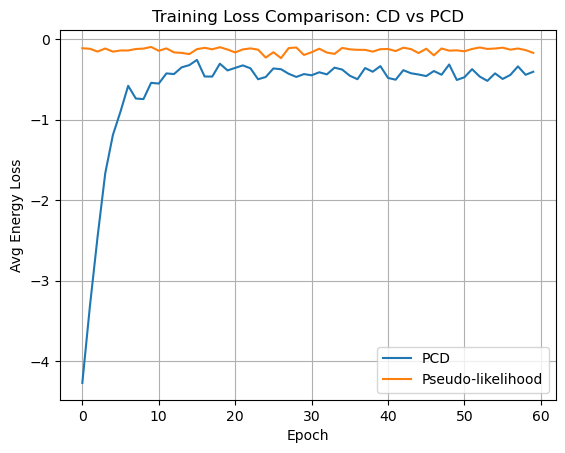

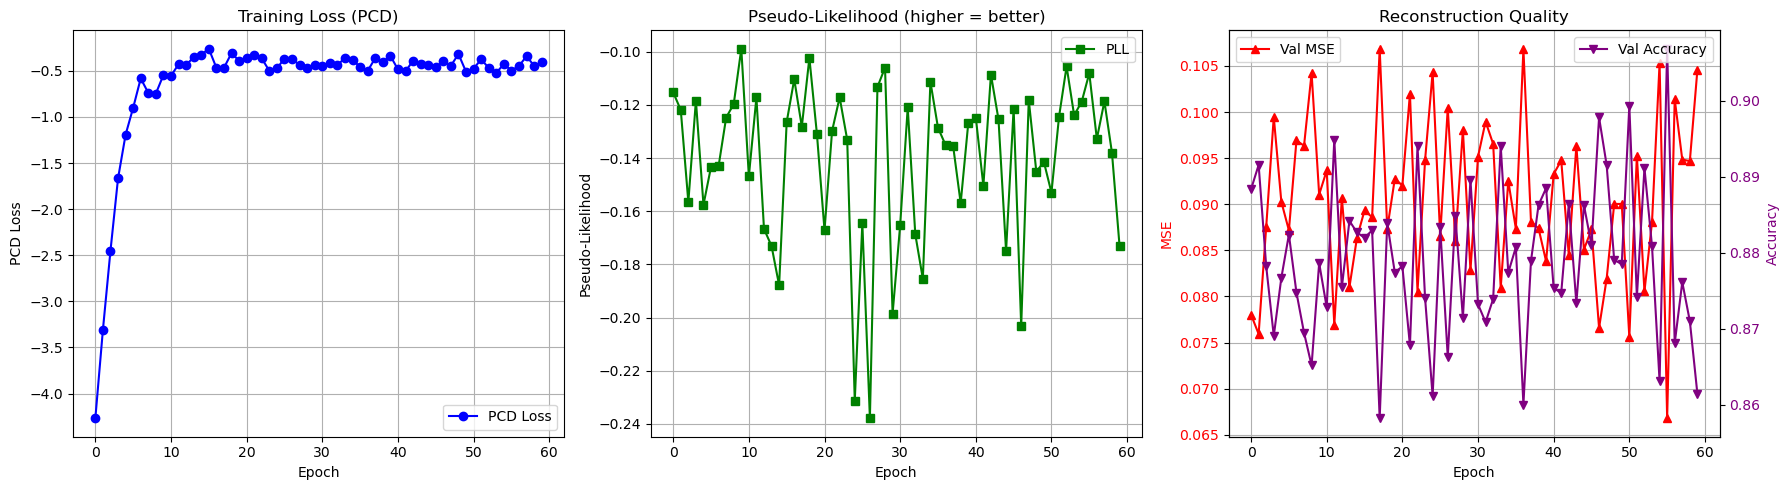

In [13]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.005 # You can change this value for experiments 
l2_amount = 1e-4 # L2 regularization amount
num_epochs = 60
batch_size = 20
num_gibbs_steps = 5


data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)



# # Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visible_set = set(visible_nodes)
hidden_set = set(hidden_nodes)

vv_edges = sum(1 for u, v in G.edges() if u in visible_set and v in visible_set)
hh_edges = sum(1 for u, v in G.edges() if u in hidden_set and v in hidden_set)
vh_edges = sum(1 for u, v in G.edges() if (u in visible_set) != (v in visible_set))

print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")


# visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
# print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)

# Pre-training visible
# pretrain_visible_biases(model_pcd, data_loader, epochs=10, lr=0.01)

# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, betas=(0.9, 0.999), eps=1e-8, weight_decay=l2_amount) # betas and eps added

# Trying to Add scheduler:
scheduler = ReduceLROnPlateau(
    optimizer_pcd, 
    mode='max',           # We want to maximize PLL (less negative = better)
    factor=0.5,           # Reduce LR by half when plateauing
    patience=5,           # Wait 5 epochs before reducing
    verbose=True,         # Print when LR changes
    min_lr=1e-5          # Don't go below this
)

print(f"Scheduler created: will reduce LR by 0.5x if no improvement for 5 epochs")

results = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                        batch_size=batch_size, step_size=step_size, scheduler=scheduler, val_data= X_val, train_data = X_train, persistent=True)

# Unpack results:
pcd_losses = results['pcd_loss']
pll_values = results['pll']
train_mse = results['train_recon_mse']
train_bce = results['train_recon_bce']
train_acc = results['train_recon_acc']
val_mse = results['val_recon_mse']
val_bce = results['val_recon_bce']
val_acc = results['val_recon_acc']


# --------------------------------------------------------------------------------------------
# Training Visualization
# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()


# Replace your plotting code with:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: PCD Loss
axes[0].plot(pcd_losses, label='PCD Loss', marker='o', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('PCD Loss')
axes[0].set_title('Training Loss (PCD)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Pseudo-Likelihood
axes[1].plot(pll_values, label='PLL', marker='s', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pseudo-Likelihood')
axes[1].set_title('Pseudo-Likelihood (higher = better)')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Reconstruction Metrics
if val_mse is not None:
    ax3a = axes[2]
    ax3b = ax3a.twinx()
    
    ax3a.plot(val_mse, label='Val MSE', marker='^', color='red')
    ax3b.plot(val_acc, label='Val Accuracy', marker='v', color='purple')
    
    ax3a.set_xlabel('Epoch')
    ax3a.set_ylabel('MSE', color='red')
    ax3b.set_ylabel('Accuracy', color='purple')
    ax3a.set_title('Reconstruction Quality')
    ax3a.tick_params(axis='y', labelcolor='red')
    ax3b.tick_params(axis='y', labelcolor='purple')
    ax3a.legend(loc='upper left')
    ax3b.legend(loc='upper right')
    ax3a.grid(True)
else:
    axes[2].text(0.5, 0.5, 'No reconstruction data', ha='center', va='center')
    axes[2].set_title('Reconstruction (not tracked)')

plt.tight_layout()
plt.show()

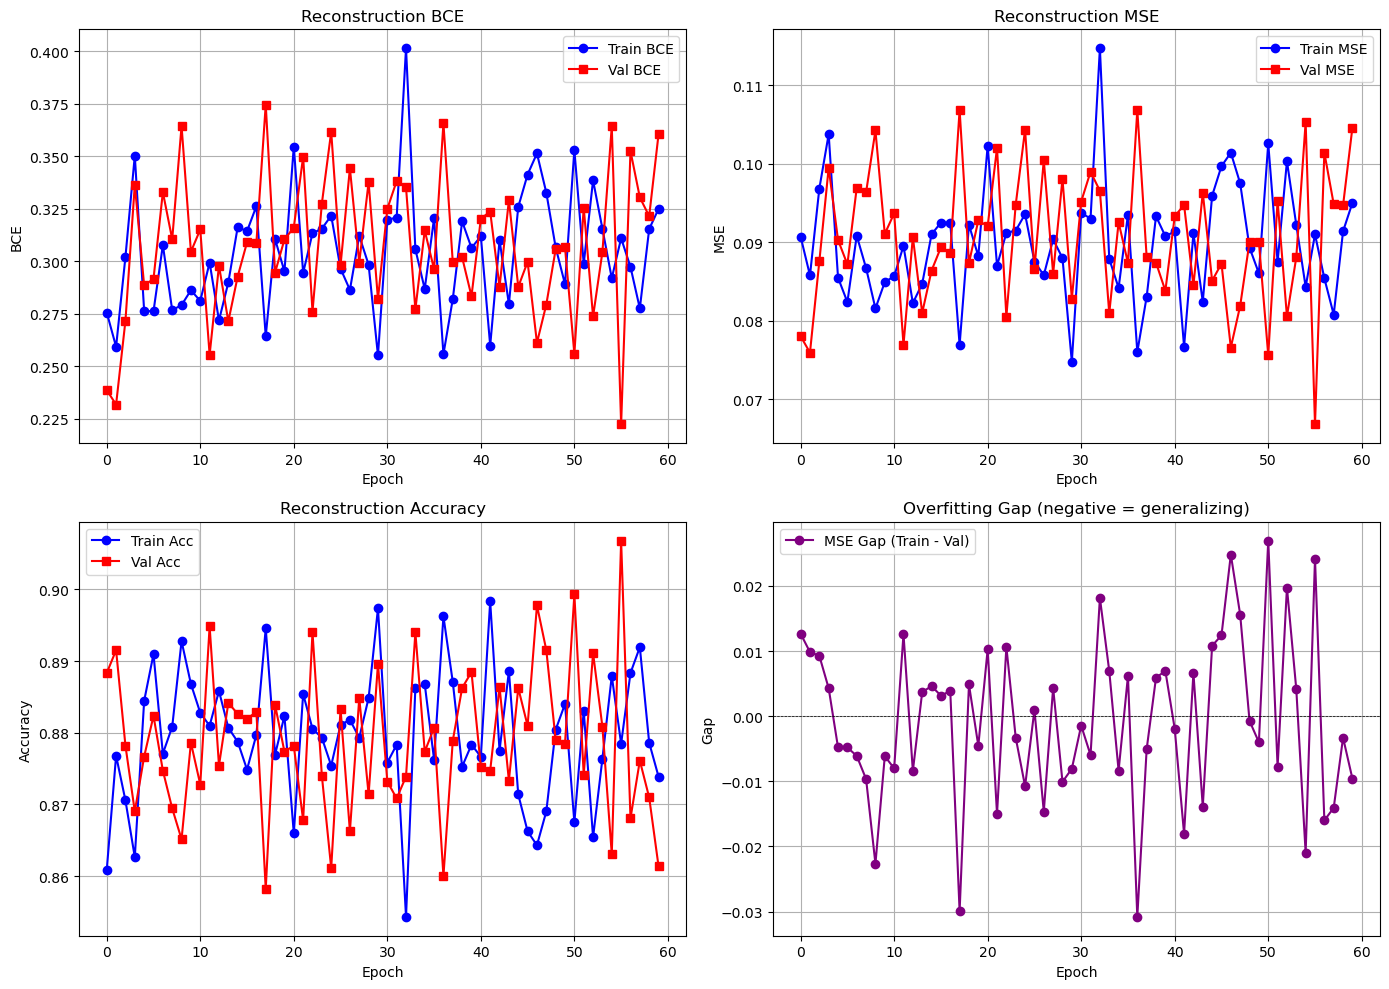

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot: Reconstruction BCE (Train vs Val)
axes[0, 0].plot(train_bce, label='Train BCE', marker='o', color='blue')
axes[0, 0].plot(val_bce, label='Val BCE', marker='s', color='red')
axes[0, 0].set_title('Reconstruction BCE')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('BCE')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot: Reconstruction MSE (Train vs Val)
axes[0, 1].plot(train_mse, label='Train MSE', marker='o', color='blue')
axes[0, 1].plot(val_mse, label='Val MSE', marker='s', color='red')
axes[0, 1].set_title('Reconstruction MSE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot: Reconstruction Accuracy (Train vs Val)
axes[1, 0].plot(train_acc, label='Train Acc', marker='o', color='blue')
axes[1, 0].plot(val_acc, label='Val Acc', marker='s', color='red')
axes[1, 0].set_title('Reconstruction Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot: Overfitting Gap
gap_mse = [t - v for t, v in zip(train_mse, val_mse)]
gap_acc = [t - v for t, v in zip(train_acc, val_acc)]
axes[1, 1].plot(gap_mse, label='MSE Gap (Train - Val)', marker='o', color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1, 1].set_title('Overfitting Gap (negative = generalizing)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Gap')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Running Gibbs sampler for 16 samples, 2000 burn-in steps each... 🔥
  Gibbs sample 1/16
  Gibbs sample 2/16
  Gibbs sample 3/16
  Gibbs sample 4/16
  Gibbs sample 5/16
  Gibbs sample 6/16
  Gibbs sample 7/16
  Gibbs sample 8/16
  Gibbs sample 9/16
  Gibbs sample 10/16
  Gibbs sample 11/16
  Gibbs sample 12/16
  Gibbs sample 13/16
  Gibbs sample 14/16
  Gibbs sample 15/16
  Gibbs sample 16/16
Gibbs sampling complete.

Displaying generated images... 🖼️


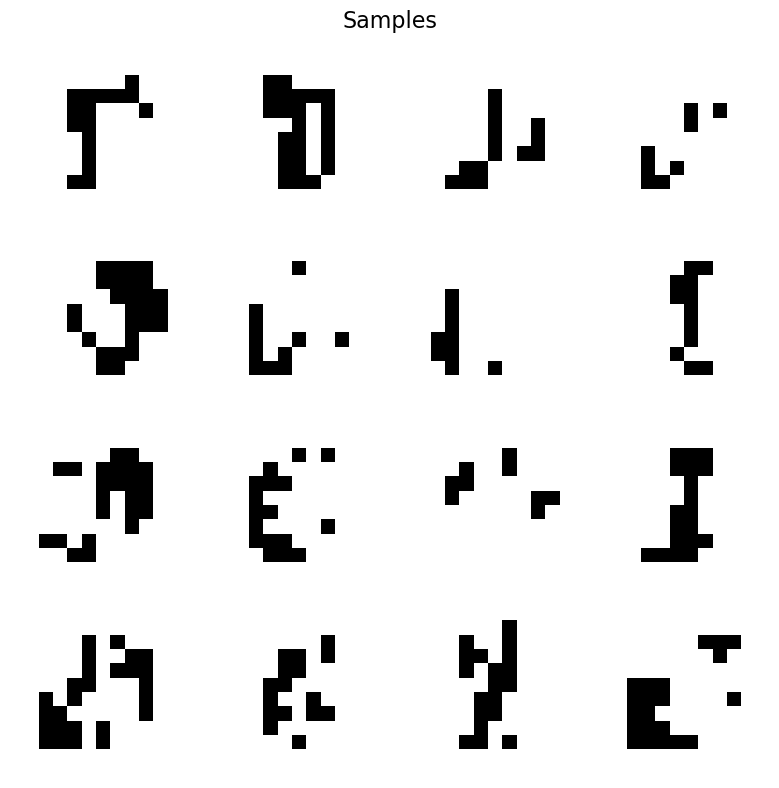

In [15]:
#--- Sampling & Visualization ---
num_gen_samples = 16
burn_in = 2000


#need to find a way to speed up these sampling functions, so slow
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples")


--- Improving samples with Tabu Search ---

Displaying Tabu Search improved images... 🖼️


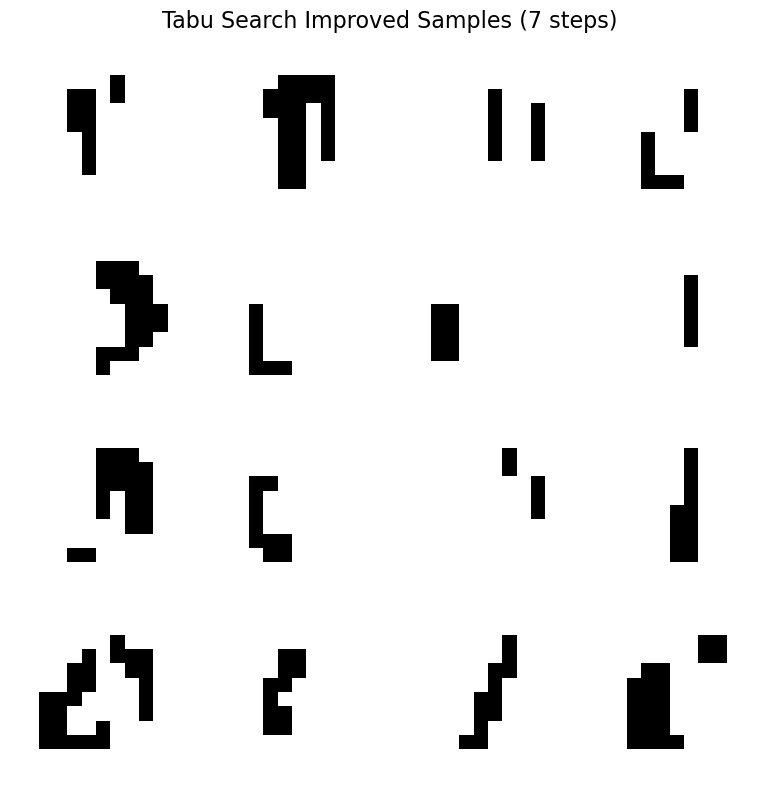

In [16]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 7
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")